# Task
The task is to summarize the entire process, including the selected best model, the impact of parameter tuning, and the final performance metrics.

The overall process involved loading and preprocessing the `cart_abandonment_data.csv` dataset, splitting it into training and testing sets, and then training and evaluating five different classification models: Logistic Regression, Decision Tree, Random Forest, Support Vector Machine (SVM), and Gradient Boosting.


## STEP 1 – LOAD DATA

### Subtask:
Load the `cart_abandonment_data.csv` dataset into a pandas DataFrame, display its head, print a concise summary, check for missing values, and display the class distribution of the target variable `Cart_Abandoned`.


In [11]:
import pandas as pd

# Load the dataset
df = pd.read_csv('cart_abandonment_data.csv')

# Display the first 5 rows
print("First 5 rows of the DataFrame:")
print(df.head())
print("\n")

# Print a concise summary
print("Concise summary of the DataFrame:")
df.info()
print("\n")

# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())
print("\n")

# Display the value counts for 'Cart_Abandoned'
print("Class distribution of 'Cart_Abandoned':")
print(df['Cart_Abandoned'].value_counts())

First 5 rows of the DataFrame:
             ID Is_Product_Details_viewed  Session_Activity_Count  \
0  Session_ID_0                       Yes                       4   
1  Session_ID_1                        No                      38   
2  Session_ID_2                        No                       8   
3  Session_ID_3                        No                       6   
4  Session_ID_4                       Yes                      31   

   No_Items_Added_InCart  No_Items_Removed_FromCart  No_Cart_Viewed  \
0                      1                          0               0   
1                      0                          0               2   
2                      5                          0               0   
3                      0                          0               2   
4                     14                         12               1   

   No_Checkout_Confirmed  No_Checkout_Initiated   No_Cart_Items_Viewed  \
0                      0                       0     

## STEP 2 – PREPROCESSING

### Subtask:
Separate features (X) and target (y). Handle categorical features like `Is_Product_Details_viewed` by mapping 'Yes'/'No' to 1/0, and one-hot encode `Customer_Segment_Type` using `pd.get_dummies`. Apply `StandardScaler` to numerical features using `ColumnTransformer` to ensure consistent preprocessing.


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd

# 1. Separate the features (X) and target (y)
X = df.drop(columns=['ID', 'Cart_Abandoned'])
y = df['Cart_Abandoned']

# 2. Convert 'Is_Product_Details_viewed' from 'Yes'/'No' to 1/0
X['Is_Product_Details_viewed'] = X['Is_Product_Details_viewed'].map({'Yes': 1, 'No': 0})

# Identify numerical and categorical columns for ColumnTransformer
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Ensure 'Customer_Segment_Type' is treated as categorical for OneHotEncoder
# It was already an int64, but for OHE it should be treated as categories.
# We will explicitly remove it from numerical_features and add it to categorical_features if not already there.
if 'Customer_Segment_Type' in numerical_features:
    numerical_features.remove('Customer_Segment_Type')
if 'Customer_Segment_Type' not in categorical_features:
    categorical_features.append('Customer_Segment_Type')


# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep any other columns not specified (if any)
)

# Fit and transform X
X_transformed = preprocessor.fit_transform(X)

# Get feature names after transformation
# numerical_features will be scaled
# categorical_features will be one-hot encoded
# ColumnTransformer.get_feature_names_out() is robust for this.

# Get names for scaled numerical features
scaled_feature_names = [f'scaled_{col}' for col in numerical_features]

# Get names for one-hot encoded categorical features
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()

# Combine all new feature names
new_feature_names = scaled_feature_names + ohe_feature_names

# Convert the transformed array back to a DataFrame with new column names
X = pd.DataFrame(X_transformed, columns=new_feature_names, index=X.index)

print("Shape of X after preprocessing:", X.shape)
print("First 5 rows of preprocessed X:")
print(X.head())
print("Class distribution of target y:")
print(y.value_counts())

Shape of X after preprocessing: (4284, 13)
First 5 rows of preprocessed X:
   scaled_Is_Product_Details_viewed  scaled_Session_Activity_Count  \
0                          1.593893                      -0.620011   
1                         -0.627395                       1.514029   
2                         -0.627395                      -0.368947   
3                         -0.627395                      -0.494479   
4                          1.593893                       1.074668   

   scaled_No_Items_Added_InCart  scaled_No_Items_Removed_FromCart  \
0                     -0.367070                         -0.282500   
1                     -0.514503                         -0.282500   
2                      0.222665                         -0.282500   
3                     -0.514503                         -0.282500   
4                      1.549566                          3.626723   

   scaled_No_Cart_Viewed  scaled_No_Checkout_Confirmed  \
0              -0.694188       

## STEP 3 – TRAIN TEST SPLIT

### Subtask:
Split the preprocessed data into training and testing sets using `train_test_split` with `test_size=0.2`, `stratify=y`, and `random_state=42`.


In [14]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nClass distribution of y_train:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution of y_test:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (3427, 13)
Shape of X_test: (857, 13)
Shape of y_train: (3427,)
Shape of y_test: (857,)

Class distribution of y_train:
Cart_Abandoned
1    0.856142
0    0.143858
Name: proportion, dtype: float64

Class distribution of y_test:
Cart_Abandoned
1    0.856476
0    0.143524
Name: proportion, dtype: float64


## STEP 4 – LOGISTIC REGRESSION

### Subtask:
Train a `LogisticRegression` model on the training data. Predict on the test set and calculate evaluation metrics: Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Store these metrics in a list of dictionaries named `results` for later comparison.


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Initialize a list to store results for all models
results = []

# Initialize and train the Logistic Regression model
lr_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
print("Training Logistic Regression model...")
lr_model.fit(X_train, y_train)
print("Logistic Regression model trained.")

# Predict on the test set
y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1] # Probability for ROC-AUC

# Calculate evaluation metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)

# Print metrics
print(f"\n--- Logistic Regression Metrics ---")
print(f"Accuracy: {accuracy_lr:.3f}")
print(f"Precision: {precision_lr:.3f}")
print(f"Recall: {recall_lr:.3f}")
print(f"F1-Score: {f1_lr:.3f}")
print(f"ROC-AUC: {roc_auc_lr:.3f}")

# Store results
results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_lr,
    'Precision': precision_lr,
    'Recall': recall_lr,
    'F1-Score': f1_lr,
    'ROC-AUC': roc_auc_lr
})
print("\nLogistic Regression results stored.")


Training Logistic Regression model...
Logistic Regression model trained.

--- Logistic Regression Metrics ---
Accuracy: 0.981
Precision: 0.999
Recall: 0.980
F1-Score: 0.989
ROC-AUC: 0.989

Logistic Regression results stored.


## STEP 5 – DECISION TREE

### Subtask:
Train a `DecisionTreeClassifier` model. Predict on the test set and calculate evaluation metrics: Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Append these metrics to the `results` list.


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
print("Training Decision Tree model...")
dt_model.fit(X_train, y_train)
print("Decision Tree model trained.")

# Predict on the test set
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1] # Probability for ROC-AUC

# Calculate evaluation metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, zero_division=0)
recall_dt = recall_score(y_test, y_pred_dt, zero_division=0)
f1_dt = f1_score(y_test, y_pred_dt, zero_division=0)
roc_auc_dt = roc_auc_score(y_test, y_proba_dt)

# Print metrics
print(f"\n--- Decision Tree Metrics ---")
print(f"Accuracy: {accuracy_dt:.3f}")
print(f"Precision: {precision_dt:.3f}")
print(f"Recall: {recall_dt:.3f}")
print(f"F1-Score: {f1_dt:.3f}")
print(f"ROC-AUC: {roc_auc_dt:.3f}")

# Store results
results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_dt,
    'Precision': precision_dt,
    'Recall': recall_dt,
    'F1-Score': f1_dt,
    'ROC-AUC': roc_auc_dt
})
print("\nDecision Tree results stored.")

Training Decision Tree model...
Decision Tree model trained.

--- Decision Tree Metrics ---
Accuracy: 0.960
Precision: 0.973
Recall: 0.981
F1-Score: 0.977
ROC-AUC: 0.909

Decision Tree results stored.


## STEP 6 – RANDOM FOREST

### Subtask:
Train a `RandomForestClassifier` model. Predict on the test set and calculate evaluation metrics: Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Append these metrics to the `results` list.


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
print("Training Random Forest model...")
rf_model.fit(X_train, y_train)
print("Random Forest model trained.")

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1] # Probability for ROC-AUC

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

# Print metrics
print(f"\n--- Random Forest Metrics ---")
print(f"Accuracy: {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.3f}")
print(f"Recall: {recall_rf:.3f}")
print(f"F1-Score: {f1_rf:.3f}")
print(f"ROC-AUC: {roc_auc_rf:.3f}")

# Store results
results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1-Score': f1_rf,
    'ROC-AUC': roc_auc_rf
})
print("\nRandom Forest results stored.")

Training Random Forest model...
Random Forest model trained.

--- Random Forest Metrics ---
Accuracy: 0.979
Precision: 0.996
Recall: 0.980
F1-Score: 0.988
ROC-AUC: 0.990

Random Forest results stored.


## STEP 7 – SUPPORT VECTOR MACHINE

### Subtask:
Train a `SVC` model with `probability=True`. Predict on the test set and calculate evaluation metrics: Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Append these metrics to the `results` list.


In [18]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize and train the Support Vector Machine (SVM) model
# Set probability=True to enable predict_proba for ROC-AUC calculation
svm_model = SVC(random_state=42, probability=True)
print("Training Support Vector Machine (SVM) model...")
svm_model.fit(X_train, y_train)
print("Support Vector Machine (SVM) model trained.")

# Predict on the test set
y_pred_svm = svm_model.predict(X_test)
y_proba_svm = svm_model.predict_proba(X_test)[:, 1] # Probability for ROC-AUC

# Calculate evaluation metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, zero_division=0)
recall_svm = recall_score(y_test, y_pred_svm, zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, zero_division=0)
roc_auc_svm = roc_auc_score(y_test, y_proba_svm)

# Print metrics
print(f"\n--- Support Vector Machine (SVM) Metrics ---")
print(f"Accuracy: {accuracy_svm:.3f}")
print(f"Precision: {precision_svm:.3f}")
print(f"Recall: {recall_svm:.3f}")
print(f"F1-Score: {f1_svm:.3f}")
print(f"ROC-AUC: {roc_auc_svm:.3f}")

# Store results
results.append({
    'Model': 'SVM',
    'Accuracy': accuracy_svm,
    'Precision': precision_svm,
    'Recall': recall_svm,
    'F1-Score': f1_svm,
    'ROC-AUC': roc_auc_svm
})
print("\nSupport Vector Machine (SVM) results stored.")

Training Support Vector Machine (SVM) model...
Support Vector Machine (SVM) model trained.

--- Support Vector Machine (SVM) Metrics ---
Accuracy: 0.977
Precision: 0.990
Recall: 0.982
F1-Score: 0.986
ROC-AUC: 0.992

Support Vector Machine (SVM) results stored.


## STEP 8 – GRADIENT BOOSTING

### Subtask:
Train a `GradientBoostingClassifier` model. Predict on the test set and calculate evaluation metrics: Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Append these metrics to the `results` list.


In [19]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize and train the Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)
print("Training Gradient Boosting model...")
gb_model.fit(X_train, y_train)
print("Gradient Boosting model trained.")

# Predict on the test set
y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1] # Probability for ROC-AUC

# Calculate evaluation metrics
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb, zero_division=0)
recall_gb = recall_score(y_test, y_pred_gb, zero_division=0)
f1_gb = f1_score(y_test, y_pred_gb, zero_division=0)
roc_auc_gb = roc_auc_score(y_test, y_proba_gb)

# Print metrics
print(f"\n--- Gradient Boosting Metrics ---")
print(f"Accuracy: {accuracy_gb:.3f}")
print(f"Precision: {precision_gb:.3f}")
print(f"Recall: {recall_gb:.3f}")
print(f"F1-Score: {f1_gb:.3f}")
print(f"ROC-AUC: {roc_auc_gb:.3f}")

# Store results
results.append({
    'Model': 'Gradient Boosting',
    'Accuracy': accuracy_gb,
    'Precision': precision_gb,
    'Recall': recall_gb,
    'F1-Score': f1_gb,
    'ROC-AUC': roc_auc_gb
})
print("\nGradient Boosting results stored.")

Training Gradient Boosting model...
Gradient Boosting model trained.

--- Gradient Boosting Metrics ---
Accuracy: 0.981
Precision: 0.999
Recall: 0.980
F1-Score: 0.989
ROC-AUC: 0.995

Gradient Boosting results stored.


## STEP 9 – MODEL COMPARISON

### Subtask:
Create a pandas DataFrame from the `results` list, comparing all models across Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Sort the DataFrame by F1 Score in descending order and display it clearly.


In [20]:
import pandas as pd

# Create a DataFrame from the results list
results_df = pd.DataFrame(results)

# Sort the DataFrame by F1-Score in descending order
results_df_sorted = results_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print("\n--- Model Performance Comparison (Sorted by F1-Score) ---")
print(results_df_sorted)



--- Model Performance Comparison (Sorted by F1-Score) ---
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.981330   0.998611  0.979564  0.988996  0.988924
1    Gradient Boosting  0.981330   0.998611  0.979564  0.988996  0.994506
2        Random Forest  0.978996   0.995845  0.979564  0.987637  0.989854
3                  SVM  0.976663   0.990385  0.982289  0.986320  0.991781
4        Decision Tree  0.960327   0.972973  0.980926  0.976934  0.909085


## STEP 10 – BEST MODEL SELECTION

### Subtask:
Analyze the comparison DataFrame to identify and print the name of the best performing model based on the F1 Score.


In [21]:
# Identify the best model based on F1-Score
best_model_name = results_df_sorted.loc[0, 'Model']
best_f1_score = results_df_sorted.loc[0, 'F1-Score']

print(f"\nBest Model Selected based on F1-Score: {best_model_name} (F1-Score: {best_f1_score:.3f})")



Best Model Selected based on F1-Score: Logistic Regression (F1-Score: 0.989)


## STEP 11 – HYPERPARAMETER TUNING

### Subtask:
Perform hyperparameter tuning on the selected best model using `GridSearchCV`. Set `cv=5` for cross-validation and `scoring='f1'` to optimize for F1 Score. Print the `best_params_` found by GridSearchCV and the `best_score_` achieved during cross-validation.


In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid for Logistic Regression (the selected best model)
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'], # 'lbfgs' works well for larger datasets; 'liblinear' for smaller and L1 penalty.
    'max_iter': [100, 200, 500]
}

# Initialize Logistic Regression model with a random state for reproducibility
lr_model_tuned = LogisticRegression(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=lr_model_tuned, param_grid=param_grid,
                           scoring='f1', cv=5, verbose=1, n_jobs=-1)

print("Performing GridSearchCV for hyperparameter tuning on Logistic Regression...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters found
print("\nBest parameters found by GridSearchCV:")
print(grid_search.best_params_)

# Print the best cross-validation F1 score
print("\nBest cross-validation F1-Score:")
print(f"{grid_search.best_score_:.3f}")

# Store the best estimator (tuned model)
best_tuned_model = grid_search.best_estimator_
print("\nBest tuned Logistic Regression model stored.")


Performing GridSearchCV for hyperparameter tuning on Logistic Regression...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters found by GridSearchCV:
{'C': 0.01, 'max_iter': 100, 'solver': 'liblinear'}

Best cross-validation F1-Score:
0.990

Best tuned Logistic Regression model stored.


## STEP 12 – EVALUATE TUNED MODEL AND COMPARE

### Subtask:
Evaluate the performance of the hyperparameter-tuned best model on the test set. Calculate its Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Create a new pandas DataFrame to compare the metrics of the untuned best model against the tuned best model, highlighting any improvements or changes in performance.


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Evaluate the tuned model on the test set
y_pred_tuned = best_tuned_model.predict(X_test)
y_proba_tuned = best_tuned_model.predict_proba(X_test)[:, 1]

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned, zero_division=0)
recall_tuned = recall_score(y_test, y_pred_tuned, zero_division=0)
f1_tuned = f1_score(y_test, y_pred_tuned, zero_division=0)
roc_auc_tuned = roc_auc_score(y_test, y_proba_tuned)

tuned_results = {
    'Model': 'Logistic Regression (Tuned)',
    'Accuracy': accuracy_tuned,
    'Precision': precision_tuned,
    'Recall': recall_tuned,
    'F1-Score': f1_tuned,
    'ROC-AUC': roc_auc_tuned
}

# Get the results for the untuned Logistic Regression model
# Assuming 'results' list still contains the untuned LR model at index 0
untuned_lr_results = results[0]

# Create a DataFrame for comparison
comparison_df = pd.DataFrame([untuned_lr_results, tuned_results])

print("\n--- Performance Comparison: Untuned vs. Tuned Logistic Regression ---")
print(comparison_df.set_index('Model').round(4))



--- Performance Comparison: Untuned vs. Tuned Logistic Regression ---
                             Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                      
Logistic Regression            0.9813     0.9986  0.9796     0.989   0.9889
Logistic Regression (Tuned)    0.9813     0.9986  0.9796     0.989   0.9826


## STEP 13 – VISUALIZATIONS

### Subtask:
Generate suitable visualizations for the tuned best model. This will include:
- A Confusion Matrix visualized as a heatmap using `seaborn`.
- An ROC Curve.
- A Precision-Recall Curve.
- If the best model is tree-based, a Feature Importance plot. If Logistic Regression (or another linear model), visualize the coefficients to represent feature impact.
Ensure all plots have appropriate titles and labels.


Generating visualizations for the tuned Logistic Regression model...


<Figure size 600x600 with 0 Axes>

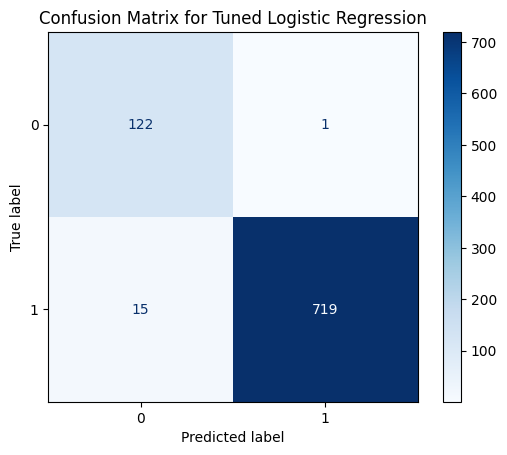

<Figure size 800x600 with 0 Axes>

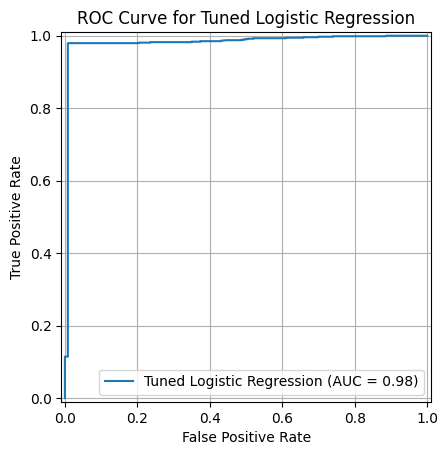

<Figure size 800x600 with 0 Axes>

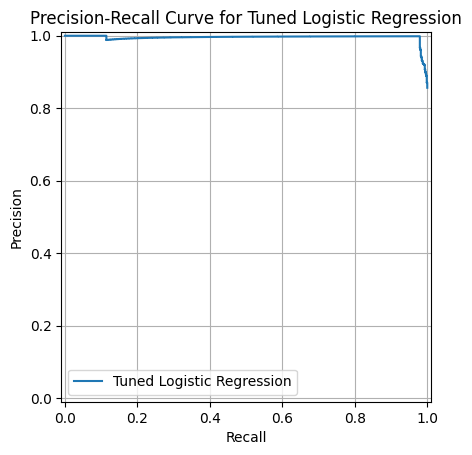

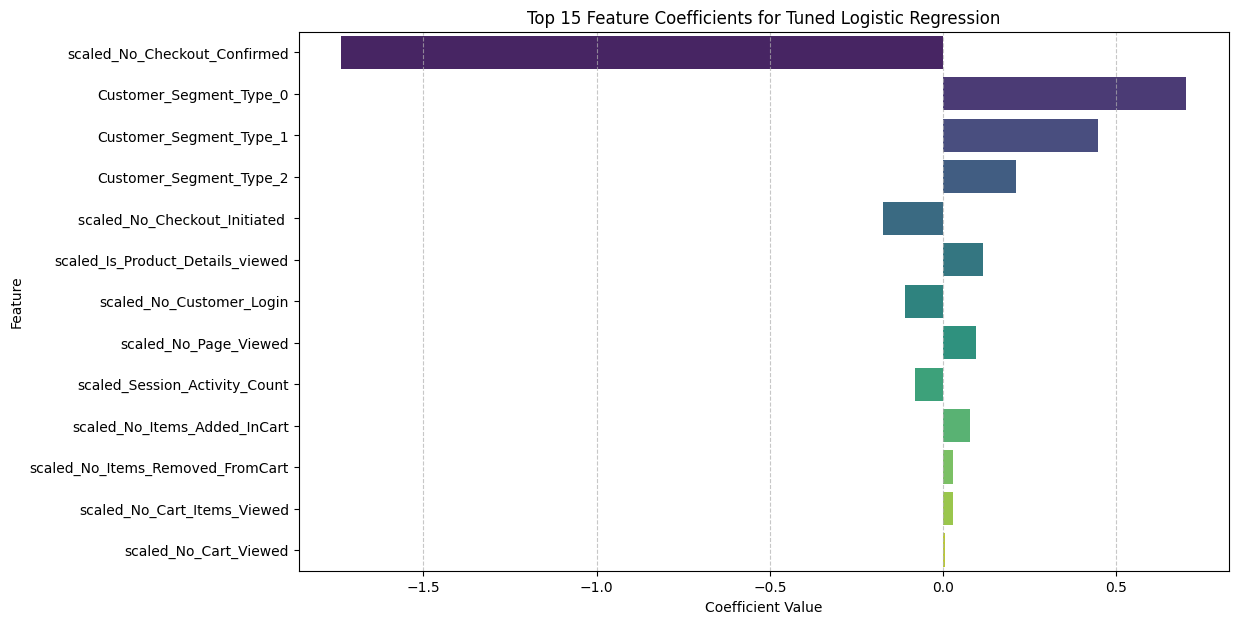

Visualizations generated successfully.


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve
import pandas as pd

print("Generating visualizations for the tuned Logistic Regression model...")

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_tuned_model.classes_)
plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Tuned Logistic Regression')
plt.show()

# 2. ROC Curve
y_proba_tuned = best_tuned_model.predict_proba(X_test)[:, 1] # Probability of the positive class (1)
fpr, tpr, _ = roc_curve(y_test, y_proba_tuned)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='Tuned Logistic Regression')
roc_display.plot()
plt.title('ROC Curve for Tuned Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba_tuned)
plt.figure(figsize=(8, 6))
pr_display = PrecisionRecallDisplay(precision=precision, recall=recall, estimator_name='Tuned Logistic Regression')
pr_display.plot()
plt.title('Precision-Recall Curve for Tuned Logistic Regression')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()
print("")
print("")
# 4. Feature Impact (Coefficients for Logistic Regression)
if hasattr(best_tuned_model, 'coef_'):
    coefficients = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': best_tuned_model.coef_[0]
    })
    coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
    coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

    plt.figure(figsize=(12, 7))
    sns.barplot(x='Coefficient', y='Feature', hue='Feature', data=coefficients.head(15), palette='viridis', legend=False)
    plt.title('Top 15 Feature Coefficients for Tuned Logistic Regression')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

print("Visualizations generated successfully.")